# PREDIÇÃO NO DATASET

- Avalia um modelo salvo nos **dados de teste do treino dele**: mesmo `test_size`, mesma semente, mesmo `DataBase.csv`.
- Sai a tabela de acurácia, precisão, recall, IoU e F1, a matriz de confusão e as predições.

In [6]:
import os, cv2, json, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import sys, gc
sys.path.append("..")
from Network.index import ModelNetwork
from Transforms.index import Transforms
from utils.index import showTile

In [7]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu118
True
Quadro P6000


# MODELO
- Base Path é a pasta dos modelos: 'Backup', '../Documents/Backups/Marcia' ou '../Documents/Backups/Backup1'
- Dataset=None é dataset do modelo; um nome (ex. 'dataset_74_wu_mar') avalia no teste dele sem os tiles do treino

In [8]:
BASE_PATH = '../Model/Backup'    
DATASET   = None                            

In [9]:
models    = sorted(os.listdir(BASE_PATH), key=lambda name: int(name.split('_')[-1]))
df_models = []

for model in models:
    info     = json.loads(open(f'{BASE_PATH}/{model}/info.json', 'r').read())
    n_images = info.get('division', info['processing']).get('n_images', {})
    
    df_models.append({
        'id': model,
        'network': info['model'].get('network'),
        'dataset': info['processing'].get('dataset'),
        'train_size': n_images.get('train'),
        'val_size': n_images.get('val'),
        'test_size': n_images.get('test'),
        'test_iou': info['trainer'].get('test_iou'),
        'path': f'{BASE_PATH}/{model}',
    })

df_models = pd.DataFrame(df_models)
df_models

,id,network,dataset,train_size,val_size,test_size,test_iou,path
0,model_1,dbnnet,dataset_wu,200,10,10,0.748029,../Model/Backup/model_1
1,model_2,dbnnet,dataset_wu,200,10,10,0.750905,../Model/Backup/model_2


In [10]:
modelId = 'model_1'
baseDir = f'{BASE_PATH}/{modelId}'

modelInfo = json.loads(open(f'{baseDir}/info.json', 'r').read())
OPTIONS   = modelInfo.get('processing')
DIVISION  = modelInfo.get('division', OPTIONS)

print(DIVISION)
OPTIONS

{'network': 'dbnnet',
 'dataset': 'dataset_wu',
 'img_size': [128, 128, 128],
 'lr': 0.0001,
 'loss': 'dice_focal',
 'batch_size': 2,
 'scheduler': 'plateau',
 'dropout': 0.1,
 'num_filters': 32,
 'ema': True,
 'epochs': 100,
 'n_trials': 3,
 'trial': 0,
 'val_size': 0.047619047619047616,
 'test_size': 0.045454545454545456,
 'n_images': {'total': 220, 'train': 200, 'val': 10, 'test': 10}}

In [11]:
model_options = modelInfo.get('model')
print(model_options)

network   = ModelNetwork(**model_options)
modelData = torch.load(f'{baseDir}/model.pth', map_location=network.device)

network.model.load_state_dict(modelData['model'])
network.model.eval()

{'network': 'dbnnet', 'img_size': [128, 128, 128], 'classes': 1, 'channels': 1, 'dropout': 0.1, 'num_filters': 32, 'lr': 0.0001}


Unet3D_V2(
  (enc1): EncoderBlock(
    (conv_block): Conv3DBlock(
      (conv1): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act1): LeakyReLU(negative_slope=0.1, inplace=True)
      (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act2): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (pool): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout3d(p=0.025, inplace=False)
  )
  (enc2): EncoderBlock(
    (conv_block): Conv3DBlock(
      (conv1): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act1): LeakyReLU(negative_slope=0.1, inplace=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1),

# SPLITS DOS DADOS

- O `TEST_SIZE` vem do `division` do `info.json` do modelo, gravado pelo `1 - Model` (backup de antes do `division` guardava o split no `processing`, e o notebook lê de lá): aqui não existe valor próprio, então não tem como treinar com um e testar com outro.
- O split é refeito igual ao do treino e as contagens têm que bater com o `n_images` gravado; se não baterem, a célula para.

In [12]:
DATABASE = f'../Dataset/{OPTIONS.get("dataset")}/DataBase.csv'
df       = pd.read_csv(DATABASE)
IMG_SIZE = tuple(model_options.get('img_size'))

# O DADO TEM DE ESTAR NA NORMALIZAÇÃO EM QUE O MODELO TREINOU (SEM A COLUNA, É O MIN-MAX DE SEMPRE)
FORMATTED = df['normalize'].iloc[0] if 'normalize' in df else True
if FORMATTED != OPTIONS.get('normalize', True):
    raise ValueError(f'{DATABASE} está com normalize={FORMATTED} e o modelo treinou com normalize={OPTIONS.get("normalize", True)}: rode o Format do dataset com o processing deste modelo')

print(f'{DATABASE}: {len(df)} volumes, janela {IMG_SIZE}')
df

../Dataset/dataset_wu/DataBase.csv: 220 volumes, janela (128, 128, 128)


,id,img_min,img_max,img_mean,img_std,msk_min,msk_max,shape,img_path,mask_path
0,0.npy,0.0,1.0,0.497236,0.211666,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
1,1.npy,0.0,1.0,0.496481,0.184599,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
2,10.npy,0.0,1.0,0.496158,0.185499,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
3,100.npy,0.0,1.0,0.496551,0.203066,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
4,101.npy,0.0,1.0,0.497007,0.210493,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
...,...,...,...,...,...,...,...,...,...,...
215,95.npy,0.0,1.0,0.495437,0.192614,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
216,96.npy,0.0,1.0,0.495381,0.201204,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
217,97.npy,0.0,1.0,0.495210,0.186244,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
218,98.npy,0.0,1.0,0.494706,0.201227,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...


In [13]:
TEST_SIZE = DIVISION.get('test_size')
TEST_SIZE

0.045454545454545456

In [14]:
temp_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42)
n_images = {'total': len(df), 'test': len(test_df)}

if any(DIVISION['n_images'][key] != n_images[key] for key in n_images):
    raise ValueError(f'split diferente do treino: {n_images} aqui, {DIVISION["n_images"]} no info.json')

n_images

{'total': 220, 'test': 10}

### Outro dataset

- Com `DATASET`, o teste é o split desse dataset com o mesmo `TEST_SIZE`, sem os tiles que o modelo já viu no treino e na validação (os mixes apontam para os mesmos arquivos dos datasets de origem).

In [15]:
if DATASET and DATASET != OPTIONS.get('dataset'):
    seen = set(temp_df.img_path)
    df   = pd.read_csv(f'../Dataset/{DATASET}/DataBase.csv')
    temp_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42)
    test_df = test_df[~test_df.img_path.isin(seen)]

print(f'{len(test_df)} volumes de teste')
test_df.img_path.str.split('/').str[-3].value_counts()

10 volumes de teste


img_path
dataset_wu    10
Name: count, dtype: int64

# DATASET

- Modelo treinado com `crop` no `augmentations` tem a janela menor que o tile: o tile vai inteiro e a predição é pela janela deslizante do `Transforms`, com o mesmo `overlap`, `mode` e lote do treino, a mesma conta do `test_iou` gravado.
- Sem `crop`, os blocos são da janela do modelo, como sempre.

In [ ]:
transforms = Transforms(OPTIONS.get('augmentations'), batch=OPTIONS.get('batch_size'))
print(f'recorte {transforms.window}: tile inteiro por janela deslizante (overlap {transforms.overlap}, {transforms.mode})' if transforms.window else f'sem recorte: blocos de {IMG_SIZE}')

In [16]:
class PredictDataset(Dataset):
    def __init__(self, df, window):
        self.df     = df.reset_index(drop=True)
        self.shape  = np.load(self.df.img_path.iloc[0], mmap_mode='r').shape
        self.window = tuple(min(int(w), int(s)) for w, s in zip(window or self.shape, self.shape))
        self.starts = [self.getStarts(s, w) for s, w in zip(self.shape, self.window)]
        self.blocks = [(row, d, h, w) for row in range(len(self.df)) for d in self.starts[0] for h in self.starts[1] for w in self.starts[2]]

    # INICIO DE CADA BLOCO NUM EIXO; O ULTIMO ENCOSTA NO FIM DO VOLUME
    @staticmethod
    def getStarts(size, window):
        return sorted(set(list(range(0, size - window + 1, window)) + [size - window]))

    def __len__(self):
        return len(self.blocks)

    def __getitem__(self, index):
        fileIndex, d, h, w = self.blocks[index]
        row = self.df.iloc[fileIndex]
        wd, wh, ww = self.window

        img  = np.asarray(np.load(row.img_path,  mmap_mode='r')[d:d + wd, h:h + wh, w:w + ww], np.float32)
        mask = np.asarray(np.load(row.mask_path, mmap_mode='r')[d:d + wd, h:h + wh, w:w + ww], np.float32)

        img_tensor  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


testDataset = PredictDataset(
    df=test_df,
    window=None if transforms.window else IMG_SIZE
)

# DATA LOADER

In [17]:
NUM_WORKERS = 2
BATCH_SIZE  = int(np.clip(128 ** 3 // int(np.prod(testDataset.window)), 1, 256))

testLoader = DataLoader(
    testDataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

# DADOS DE TESTE

- Voxels de todos os tiles de teste somados (`tp`, `fp`, `fn`, `tn`) antes de dividir, a mesma conta do `test_iou` do treino.

In [18]:
def getCounts(network, loader, amp=False):
    network.model.eval()
    tp = fp = fn = tn = 0

    with torch.no_grad(), torch.autocast('cuda', enabled=amp):
        for imgs, masks in tqdm(loader, desc='Avaliando'):
            imgs, masks = imgs.to(network.device), masks.to(network.device)
            logits = transforms.infer(network.model, imgs)

            if network.multiclass:
                preds  = torch.argmax(logits, dim=1)
                target = masks.squeeze(1) if masks.dim() == 5 else masks
            else:
                preds  = (torch.sigmoid(logits) > 0.5)
                target = masks

            achou = preds.bool()
            falha = target.bool()

            tp += int((achou & falha).sum())
            fp += int((achou & ~falha).sum())
            fn += int((~achou & falha).sum())
            tn += int((~achou & ~falha).sum())

    return (tp, fp, fn, tn)


tp, fp, fn, tn = getCounts(network, testLoader, amp=OPTIONS.get('amp', False))
tp, fp, fn, tn

Avaliando: 100%|██████████| 10/10 [00:10<00:00,  1.07s/it]


(1215474, 210773, 198655, 19346618)

In [19]:
testTable = pd.DataFrame([{
    'dataset':   DATASET or OPTIONS.get('dataset'),
    'accuracy':  (tp + tn) / (tp + fp + fn + tn),
    'precision': tp / (tp + fp),
    'recall':    tp / (tp + fn),
    'iou':       tp / (tp + fp + fn),
    'f1':        2 * tp / (2 * tp + fp + fn),
}])

testTable

,dataset,accuracy,precision,recall,iou,f1
0,dataset_wu,0.980477,0.852218,0.859521,0.748029,0.855854


# MATRIZ DE CONFUSÃO

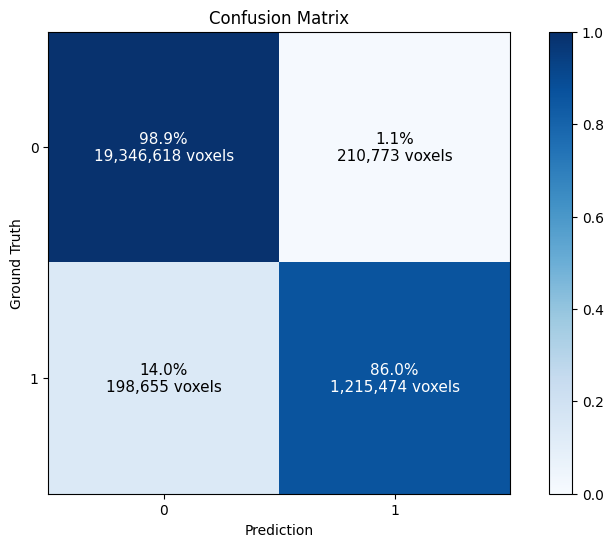

In [20]:
# MATRIZ DE CONFUSAO DOS VOXELS; A COR E A FRACAO DA CLASSE REAL (LINHA), O TEXTO TRAZ TAMBEM A CONTAGEM
def plotConfusion(tp, fp, fn, tn, title=None, save=None):
    matrix = np.array([[tn, fp], [fn, tp]])
    rates  = matrix / matrix.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    image = ax.imshow(rates, cmap='Blues', vmin=0, vmax=1)
    fig.colorbar(image, ax=ax)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{rates[i, j]:.1%}\n{matrix[i, j]:,} voxels', ha='center', va='center', fontsize=11, color='white' if rates[i, j] > 0.5 else 'black')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlabel('Prediction'), ax.set_ylabel('Ground Truth')
    ax.set_title(title)
    if not save:
        return plt.show()
    plt.savefig(save, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)


plotConfusion(tp, fp, fn, tn, title=f'Confusion Matrix')

# PROTOCOLO DO ARTIGO

- A Tabela 2 da ResACEUnet mede em recortes 96³ sorteados metade num voxel de falha e metade no fundo (o `RandCropByPosNegLabeld` da validação deles), uma métrica por recorte, e tira a média; acima são os voxels do tile inteiro somados.
- Aqui são `CROPS` recortes por volume de teste, sorteados pelo mesmo recorte do `Transforms` com semente fixa, e a rede prediz o recorte direto, como lá. Só vale para modelo treinado em recorte.
- No código deles a precisão e o recall estão trocados (`compute_prec(outputs, targets)` conta FN no lugar de FP): a coluna Precision da Tabela 2 é o recall e a Recall é a precisão. IoU e F1 não mudam.

In [ ]:
CROPS = 8

# MÉTRICAS POR RECORTE COMO NO val() DO main.py DA RESACEUNET: LIMIAR 0,5 NA SIGMOIDE E MÉDIA SOBRE OS RECORTES
def getCropMetrics(network, df, window, crops=CROPS, amp=False):
    sampler = Transforms({'crop': {'size': list(window), 'pos': 1, 'neg': 1}}, seed=42)
    rows    = []
    network.model.eval()

    with torch.no_grad(), torch.autocast('cuda', enabled=amp):
        for index, row in enumerate(tqdm(df.itertuples(), total=len(df), desc='Recortes')):
            img, mask = np.load(row.img_path).astype(np.float32), np.load(row.mask_path).astype(np.float32)

            for crop in range(crops):
                x, y   = sampler.apply(img, mask, epoch=crop, index=index)
                logits = network.model(torch.from_numpy(x)[None, None].to(network.device))
                achou  = (torch.sigmoid(logits) > 0.5)[0, 0].cpu().numpy()
                falha  = y > 0.5

                tp, fp = int((achou & falha).sum()), int((achou & ~falha).sum())
                fn, tn = int((~achou & falha).sum()), int((~achou & ~falha).sum())
                rows.append({'accuracy': (tp + tn) / achou.size, 'precision': tp / (tp + fp) if tp + fp else 0.0, 'recall': tp / (tp + fn) if tp + fn else 0.0, 'iou': tp / (tp + fp + fn) if tp + fp + fn else np.nan})

    rows = pd.DataFrame(rows)
    rows['f1'] = (2 * rows.precision * rows.recall / (rows.precision + rows.recall)).fillna(0.0)
    return rows


crops = getCropMetrics(network, test_df, transforms.window, amp=OPTIONS.get('amp', False)) if transforms.window else pd.DataFrame()
print(f'{len(crops)} recortes ({CROPS} por volume de teste)' if len(crops) else 'modelo sem recorte: o protocolo do artigo não se aplica')
pd.DataFrame([{'protocolo': 'tile inteiro (voxels somados)', **testTable.drop(columns='dataset').iloc[0].to_dict()}] + ([{'protocolo': 'artigo (média por recorte)', **crops.mean().to_dict()}] if len(crops) else []))

# PREDIÇÕES

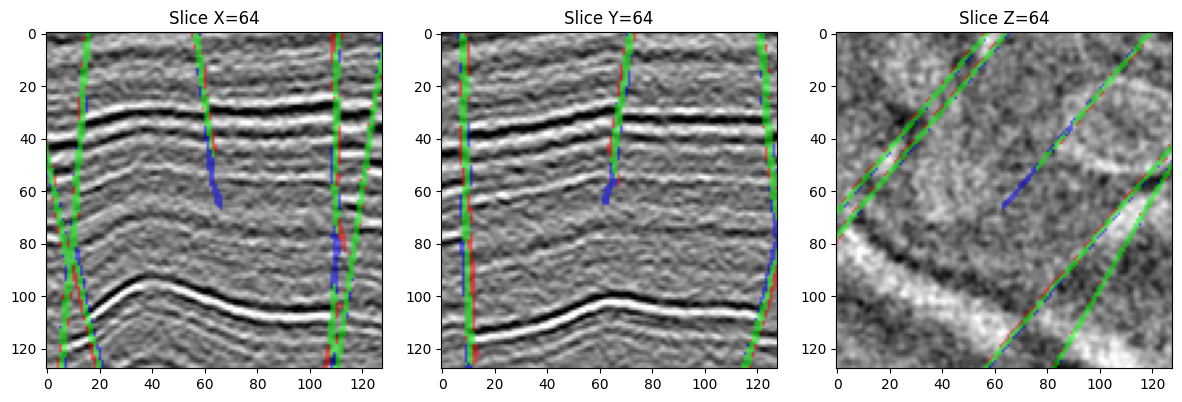

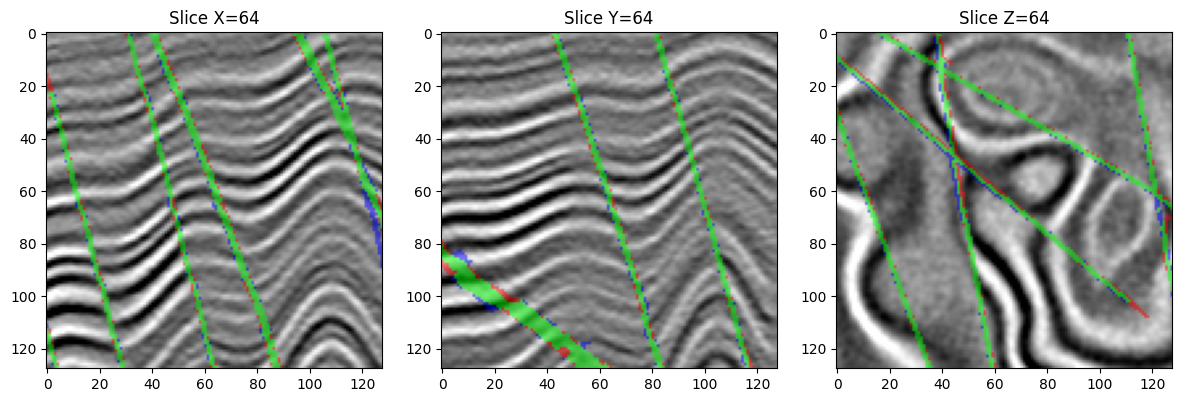

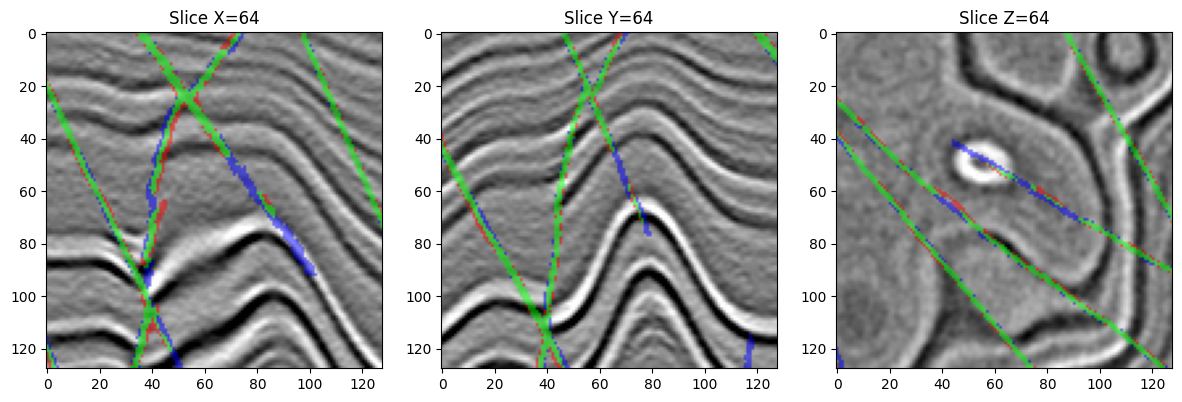

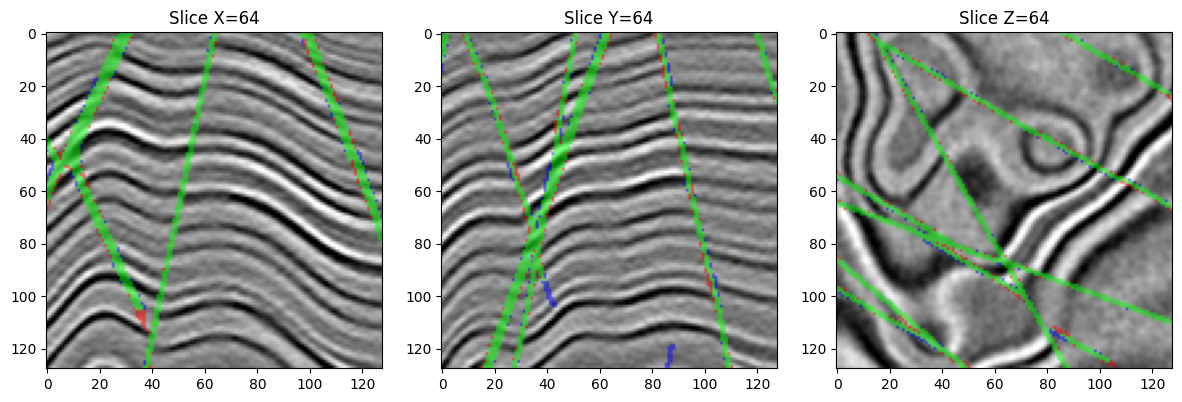

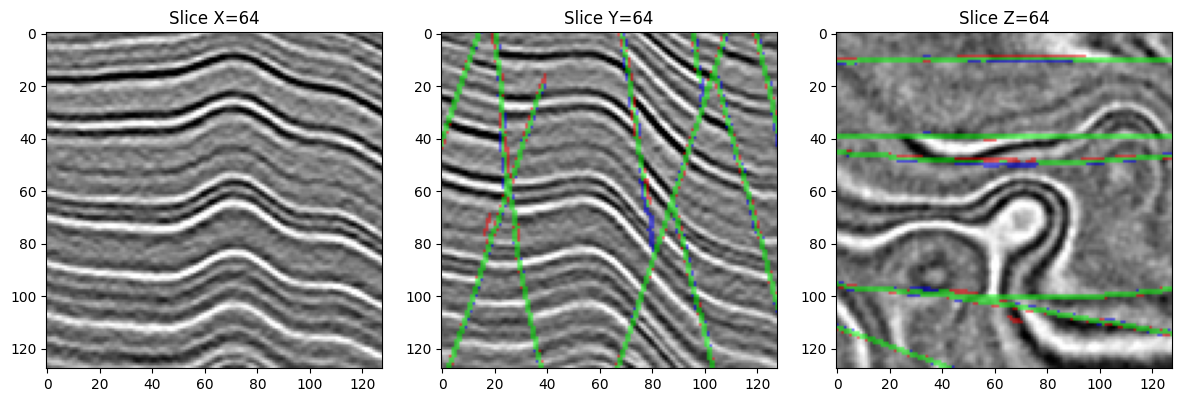

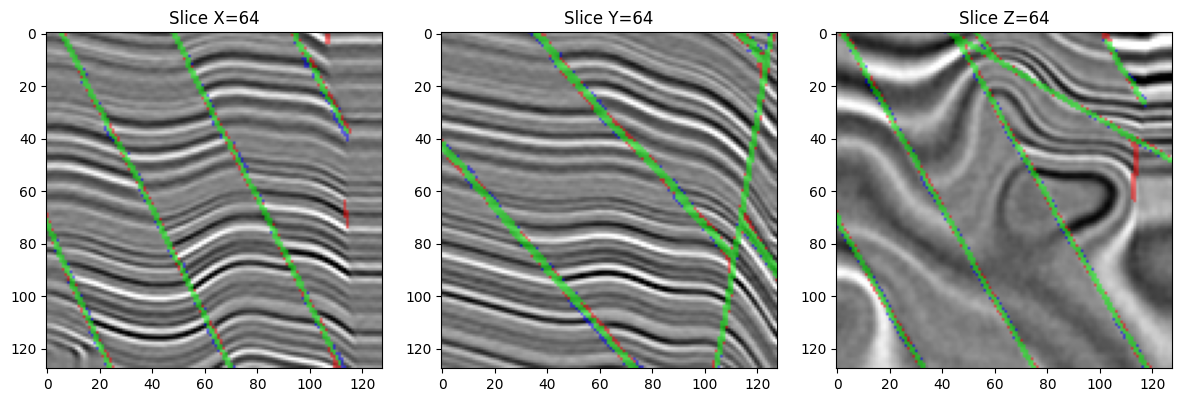

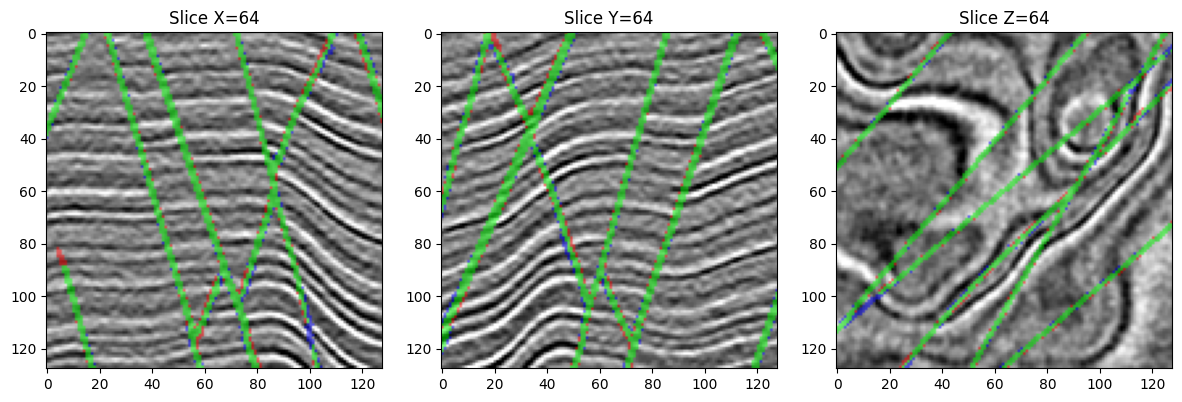

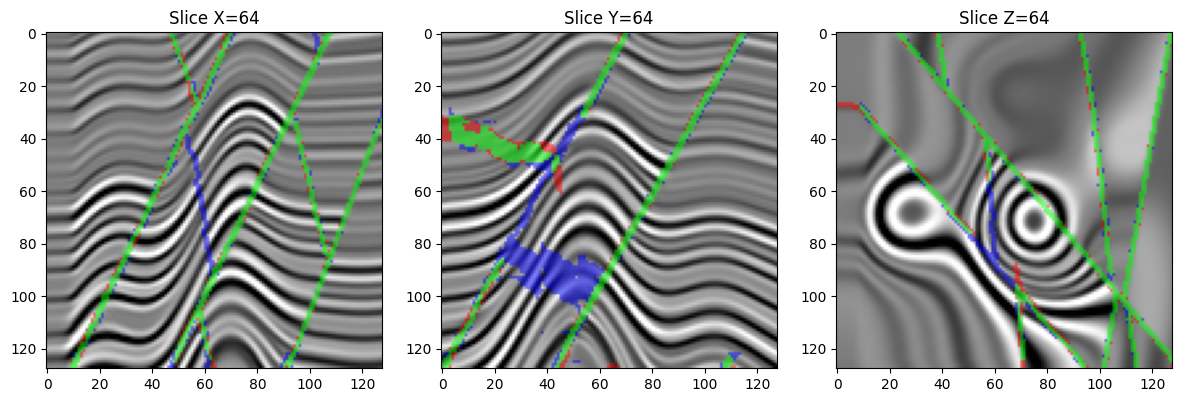

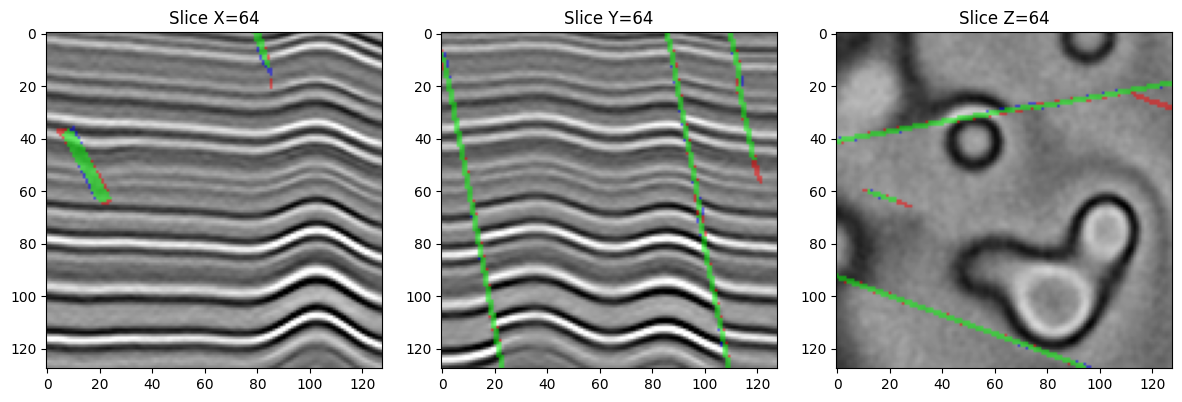

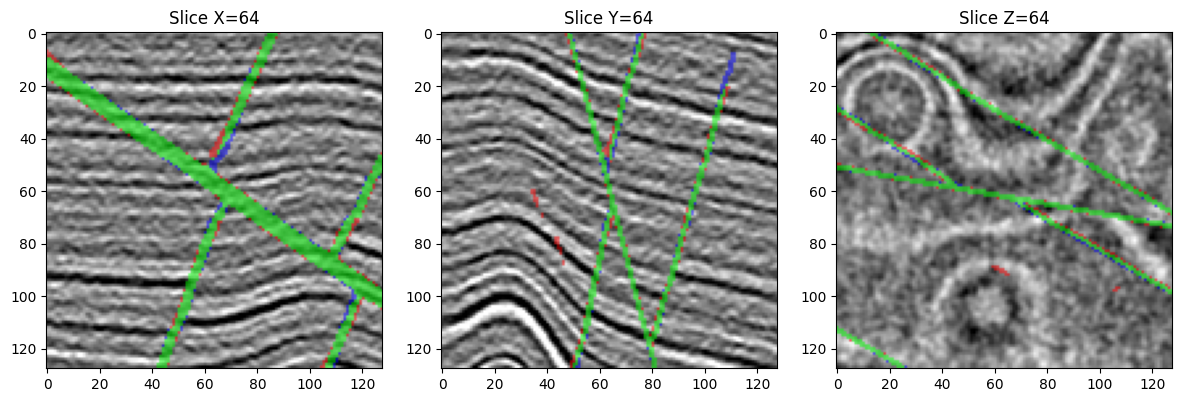

In [21]:
def plotPrediction(index, dataset=testDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits    = transforms.infer(network.model, img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    inters  = (is_gt & is_pred)   # Acertos / Interseção

    overlay[is_gt]   = [0, 0, 255]  # Azul para o Ground Truth (Falhas reais não detectadas)
    overlay[is_pred] = [255, 0, 0]  # Vermelho para a Predição (Falsos alarmes)
    overlay[inters]  = [0, 255, 0]  # verde onde Predição e GT convergem (Acertos)

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)
        

for i in range(min(len(testDataset), 15)):
    plotPrediction(index=i, dataset=testDataset, network=network)